In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:


train = pd.read_csv('../input/titanic/train.csv')
test = pd.read_csv('../input/titanic/test.csv')
df= pd.read_csv('../input/titanic/train.csv')



In [3]:
train.head()




,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:


test.head()





,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [5]:
train.info

<bound method DataFrame.info of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                   

In [6]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


In [7]:
train.drop(['PassengerId', 'Name', 'Ticket', 'Fare',"Embarked"], axis = 1, inplace = True)
train.loc[train['Sex']=='male','Sex'] = 1
train.loc[train['Sex']=='female', 'Sex'] = 0

In [8]:


train['Survived'].value_counts()



0    549
1    342
Name: Survived, dtype: int64

<AxesSubplot:xlabel='Survived', ylabel='count'>

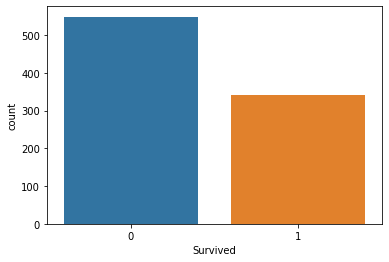

In [9]:


sns.countplot(data=train, x='Survived')



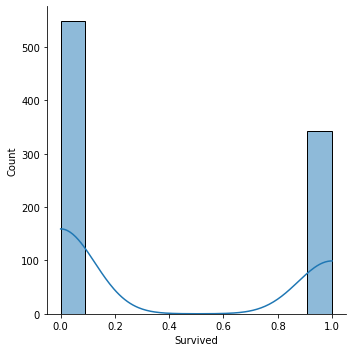

In [10]:
sns.displot(df['Survived'], kde=True)

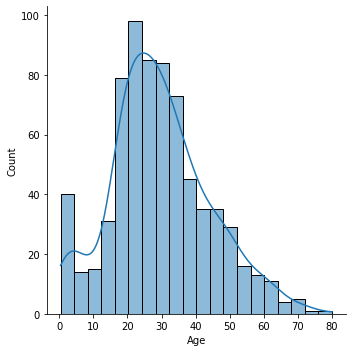

In [11]:
sns.displot(df['Age'], kde=True)

In [12]:
train.corr()['Survived'].sort_values()

Pclass     -0.338481
Age        -0.077221
SibSp      -0.035322
Parch       0.081629
Survived    1.000000
Name: Survived, dtype: float64

<AxesSubplot:xlabel='Age', ylabel='Sex'>

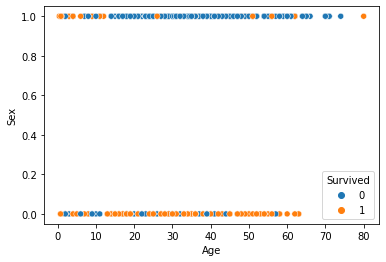

In [13]:
sns.scatterplot(data=train, x='Age', y='Sex',hue='Survived')

<AxesSubplot:xlabel='Survived', ylabel='Age'>

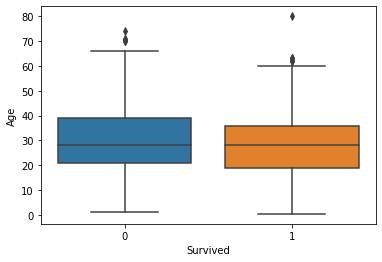

In [14]:


sns.boxplot(data=train, x='Survived', y='Age')



In [15]:
train.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Cabin       687
dtype: int64

In [16]:
100*(train.isnull().sum()/len(train))

Survived     0.000000
Pclass       0.000000
Sex          0.000000
Age         19.865320
SibSp        0.000000
Parch        0.000000
Cabin       77.104377
dtype: float64

In [17]:
def missing_percent(train):
    nan_percent= 100*(train.isnull().sum()/len(train))
    nan_percent= nan_percent[nan_percent>0].sort_values()
    return nan_percent

In [18]:
nan_percent= missing_percent(train)

In [19]:
nan_percent


Age      19.865320
Cabin    77.104377
dtype: float64

(array([0, 1]), [Text(0, 0, 'Age'), Text(1, 0, 'Cabin')])

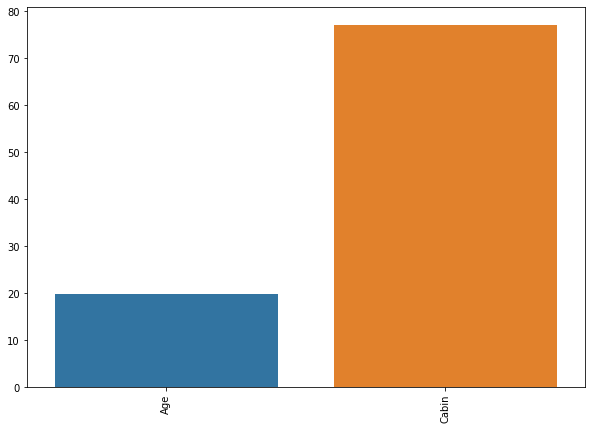

In [20]:
plt.figure(figsize=(10,7))
sns.barplot(x=nan_percent.index, y=nan_percent)
plt.xticks(rotation=90)

(0.0, 1.0)

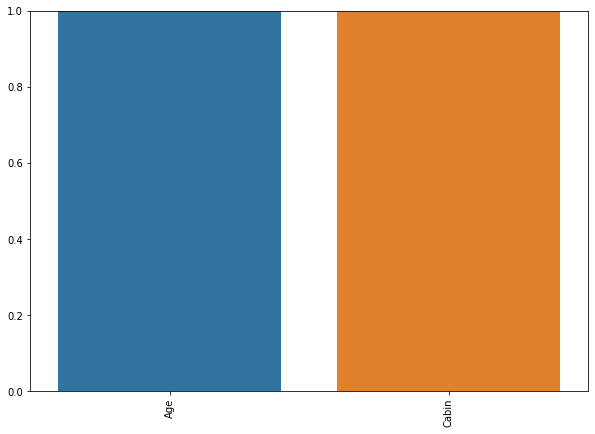

In [21]:
plt.figure(figsize=(10,7))
sns.barplot(x=nan_percent.index, y=nan_percent)
plt.xticks(rotation=90)
plt.ylim(0,1)




In [22]:


nan_percent[nan_percent<1]



Series([], dtype: float64)

In [23]:


train.drop("Cabin", axis = 1, inplace = True)



In [24]:
train["Age"].fillna(train["Age"].mean(), inplace = True)

In [25]:
train.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
dtype: int64

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, plot_confusion_matrix
from sklearn.metrics import precision_recall_curve, plot_precision_recall_curve, plot_roc_curve
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn import metrics
%matplotlib inline

In [27]:

X = train.drop("Survived", axis = 1, inplace = False)
y = train["Survived"]


In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=101)

In [29]:
scaler=StandardScaler()
scaler.fit(X_train)



StandardScaler()

In [30]:
scaler_train=scaler.transform(X_train)
scaler_test=scaler.transform(X_test)

In [31]:
knn_model=KNeighborsClassifier(n_neighbors=1)
knn_model.fit(scaler_train,y_train)

KNeighborsClassifier(n_neighbors=1)

In [32]:


y_pred=knn_model.predict(scaler_test)



In [33]:
pd.DataFrame({'Y test':y_test,'Y predict':y_pred})

,Y test,Y predict
331,0,0
700,1,1
748,0,0
751,1,1
481,0,0
...,...,...
320,0,0
288,1,0
827,1,1
847,0,0


In [34]:


accuracy_score(y_test,y_pred)



0.7222222222222222

In [35]:
confusion_matrix(y_test,y_pred)

array([[43,  8],
       [17, 22]])

In [36]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.72      0.84      0.77        51
           1       0.73      0.56      0.64        39

    accuracy                           0.72        90
   macro avg       0.72      0.70      0.71        90
weighted avg       0.72      0.72      0.72        90



In [37]:


test_error_rate=[]
for k in range(1,11):
    knn_midel=KNeighborsClassifier(n_neighbors=k)
    knn_midel.fit(scaler_train,y_train)
    y_p_test=knn_midel.predict(scaler_test)
    test_error=1-accuracy_score(y_test,y_p_test)
    test_error_rate.append(test_error)



In [38]:
test_error_rate

[0.2777777777777778,
 0.2222222222222222,
 0.21111111111111114,
 0.1777777777777778,
 0.1777777777777778,
 0.2222222222222222,
 0.23333333333333328,
 0.24444444444444446,
 0.23333333333333328,
 0.23333333333333328]

Text(0, 0.5, 'Error')

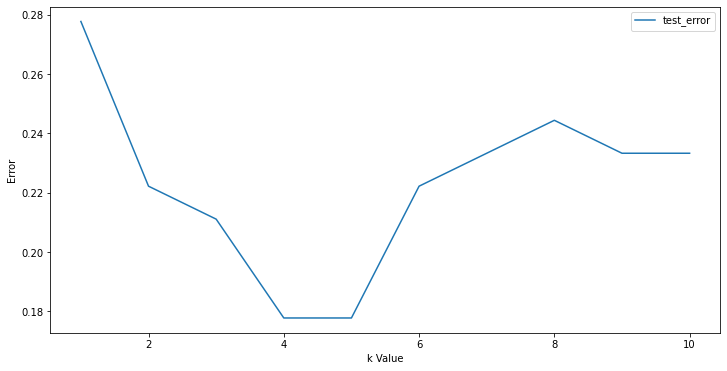

In [39]:


plt.figure(figsize=(12,6))
plt.plot(range(1,11),test_error_rate,label='test_error')
plt.legend()
plt.xlabel('k Value')
plt.ylabel('Error')



In [40]:


accuracies = []
k_values=list(range(1,11))
X=scaler_train
y=y_train
for k in k_values:
    # instantiate kNN with given neighbor size k
    knn = KNeighborsClassifier(n_neighbors=k)
   
    scores =cross_val_score(knn, X, y, cv=10,scoring='accuracy', n_jobs=-1)
    accuracies.append(scores.mean())
print(accuracies)    



[0.7502932098765431, 0.7877777777777778, 0.8026851851851852, 0.8014814814814816, 0.7927314814814815, 0.8014969135802469, 0.7977314814814815, 0.8002160493827161, 0.7977160493827161, 0.8039814814814814]


Text(0.5, 0.98, 'kNN hyperparameter (k) tuning with sklearn')

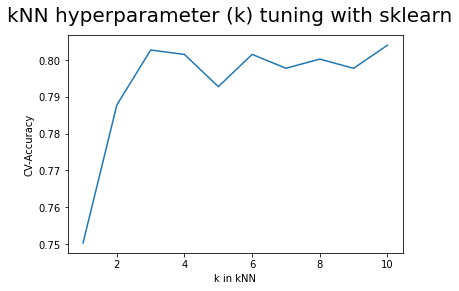

In [41]:
fig2 = plt.figure()
plt.plot(k_values, accuracies)
plt.xlabel('k in kNN')
plt.ylabel('CV-Accuracy')
fig2.suptitle('kNN hyperparameter (k) tuning with sklearn', fontsize=20)